# Prediction du Nutri-Score   IterativeImputer (ExtraTrees / BayesianRidge)

| Fichier | Role |
|---|---|
| `traite_avec_nutriscore.csv` | Donnees d'**entrainement** (produits avec grade etabli) |
| `traite_sans_nutriscore.csv` | Produits a **predire** (grade inconnu) |

## Pipeline
1. Chargement des deux datasets
2. **Imputation iterative** des valeurs manquantes (IterativeImputer)
   - Estimateur : `ExtraTreesClassifier` (par defaut) ou `BayesianRidge`
3. Entrainement d'un classificateur sur les donnees imputees
4. **Cross-Validation** (Stratified K-Fold, k=5)
5. Evaluation finale (rapport, matrice de confusion)
6. Prediction sur les produits sans Nutri-Score
7. Sauvegarde CSV

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Chargement des deux datasets

In [29]:
# --- Colonnes nutritionnelles = features du modele ---
FEATURES = [
    'energy_100g',
    'sugars_100g',
    'saturated-fat_100g',
    'salt_100g',
    'fiber_100g',
    'proteins_100g',
    'fruits-vegetables-legumes_100g',
]
TARGET = 'nutriscore_grade'
GRADES_VALIDES = ['a', 'b', 'c', 'd', 'e']

def charger(path):
    import os
    for p in [path, '../' + path, 'Nutri/' + path]:
        if os.path.exists(p):
            return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Introuvable : {path}")

# --- Dataset d'entrainement ---
df_train = charger('traité_avec_nutriscore.csv')
df_train[TARGET] = df_train[TARGET].str.lower().str.strip()
df_train = df_train[df_train[TARGET].isin(GRADES_VALIDES)]

# --- Dataset de prediction ---
df_pred = charger('traité_sans_nutriscore.csv')

print(f"Entrainement  : {len(df_train):,} produits")
print(f"A predire     : {len(df_pred):,} produits")
print(f"\nDistribution des grades (entrainement) :")
print(df_train[TARGET].value_counts())

Entrainement  : 104,313 produits
A predire     : 32,394 produits

Distribution des grades (entrainement) :
nutriscore_grade
d    25160
c    24970
e    24673
a    17788
b    11722
Name: count, dtype: int64


In [30]:
features_dispo = [f for f in FEATURES if f in df_train.columns]
print(f"Features utilisees ({len(features_dispo)}) : {features_dispo}")

X = df_train[features_dispo]
y = df_train[TARGET]

# Hold-out final 20 % pour la matrice de confusion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain : {len(X_train):,}  |  Test (hold-out) : {len(X_test):,}")

Features utilisees (6) : ['sugars_100g', 'saturated-fat_100g', 'salt_100g', 'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g']

Train : 83,450  |  Test (hold-out) : 20,863


## 2. Pipeline sklearn

### IterativeImputer

L'`IterativeImputer` impute chaque feature manquante en construisant un modele de regression
sur les autres features, puis en iterant jusqu'a convergence.

Deux estimateurs sont proposes :
- **`ExtraTreesRegressor`** (arbre) : rapide, non-parametrique, gere bien les non-linearites.
- **`BayesianRidge`** (lineaire bayesien) : plus sober, utile quand les relations sont lineaires.

Changez `ESTIMATEUR` pour basculer entre les deux.

In [ ]:
# Choix de l'estimateur pour l'IterativeImputer
# ESTIMATEUR = 'BayesianRidge'   # decommenter pour utiliser BayesianRidge
ESTIMATEUR = 'ExtraTrees'

if ESTIMATEUR == 'ExtraTrees':
    imputer_estimator = ExtraTreesRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
else:  # BayesianRidge
    imputer_estimator = BayesianRidge()

pipeline = Pipeline([
    ('imputer', IterativeImputer(
        estimator=imputer_estimator,
        max_iter=20,
        random_state=42,
        verbose=0
    )),
    ('clf', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

print(f"Pipeline cree avec IterativeImputer (estimateur={ESTIMATEUR}) + GradientBoostingClassifier")

Pipeline cree avec IterativeImputer (estimateur=BayesianRidge) + GradientBoostingClassifier


## 3. Cross-Validation Stratifiee (k = 5)

La **StratifiedKFold** garantit que chaque fold respecte la distribution des grades.
On mesure l'accuracy et le F1-macro sur les 5 folds.

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)

df_cv = pd.DataFrame({
    'Fold'           : range(1, 6),
    'Train Accuracy' : cv_results['train_accuracy'].round(4),
    'Val Accuracy'   : cv_results['test_accuracy'].round(4),
    'Val F1-macro'   : cv_results['test_f1_macro'].round(4),
})

print(df_cv.to_string(index=False))
print(f"\nMoyenne Val Accuracy : {df_cv['Val Accuracy'].mean():.4f} +/- {df_cv['Val Accuracy'].std():.4f}")
print(f"Moyenne Val F1-macro : {df_cv['Val F1-macro'].mean():.4f} +/- {df_cv['Val F1-macro'].std():.4f}")

 Fold  Train Accuracy  Val Accuracy  Val F1-macro
    1          0.9093        0.8759        0.8629
    2          0.9086        0.8736        0.8604
    3          0.9082        0.8753        0.8620
    4          0.9083        0.8700        0.8570
    5          0.9106        0.8692        0.8570

Moyenne Val Accuracy : 0.8728 +/- 0.0031
Moyenne Val F1-macro : 0.8599 +/- 0.0028


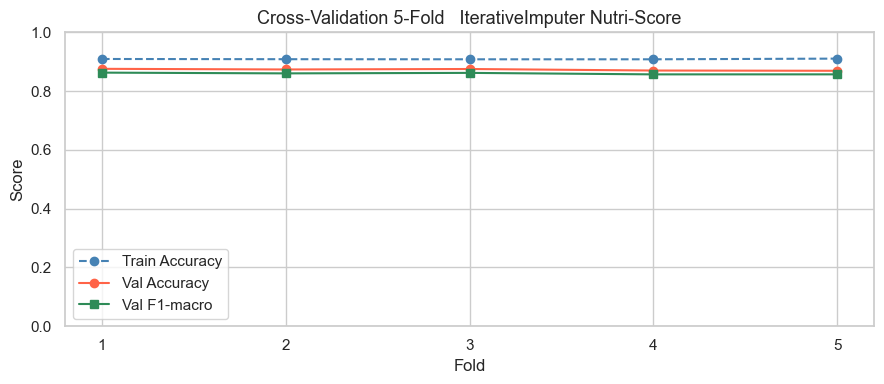

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(1, 6)
ax.plot(x, cv_results['train_accuracy'], 'o--', label='Train Accuracy', color='steelblue')
ax.plot(x, cv_results['test_accuracy'],  'o-',  label='Val Accuracy',   color='tomato')
ax.plot(x, cv_results['test_f1_macro'],  's-',  label='Val F1-macro',   color='seagreen')
ax.set_xticks(list(x))
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Cross-Validation 5-Fold   IterativeImputer Nutri-Score', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Evaluation finale sur le Hold-out (20 %)

In [34]:
# Entrainement sur 100% du train set
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Hold-out Accuracy : {acc:.4f}\n")
print(classification_report(y_test, y_pred, digits=4))

Hold-out Accuracy : 0.8754

              precision    recall  f1-score   support

           a     0.9006    0.8988    0.8997      3558
           b     0.7581    0.7449    0.7515      2344
           c     0.8321    0.8734    0.8523      4994
           d     0.8919    0.8688    0.8802      5032
           e     0.9424    0.9291    0.9357      4935

    accuracy                         0.8754     20863
   macro avg     0.8650    0.8630    0.8639     20863
weighted avg     0.8760    0.8754    0.8755     20863



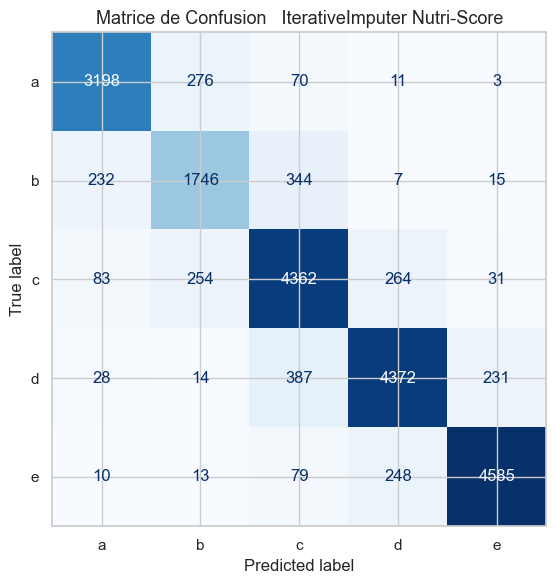

In [35]:
cm = confusion_matrix(y_test, y_pred, labels=['a','b','c','d','e'])
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['a','b','c','d','e'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de Confusion   IterativeImputer Nutri-Score', fontsize=13)
plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import classification_report
import pandas as pd

# Rapport de classification sous forme de DataFrame
report = classification_report(y_test, y_pred, digits=4, output_dict=True)
df_report = pd.DataFrame(report).T
df_report['support'] = df_report['support'].astype(int)

print("=== Rapport de classification (hold-out 20%) ===")
display(df_report.style
    .format({'precision': '{:.4f}', 'recall': '{:.4f}', 'f1-score': '{:.4f}', 'support': '{:,d}'})
    .background_gradient(subset=['precision', 'recall', 'f1-score'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption(f"Hold-out Accuracy : {acc:.4f}")
)

=== Rapport de classification (hold-out 20%) ===


,precision,recall,f1-score,support
a,0.9006,0.8988,0.8997,"3,558"
b,0.7581,0.7449,0.7515,"2,344"
c,0.8321,0.8734,0.8523,"4,994"
d,0.8919,0.8688,0.8802,"5,032"
e,0.9424,0.9291,0.9357,"4,935"
accuracy,0.8754,0.8754,0.8754,0
macro avg,0.8650,0.8630,0.8639,"20,863"
weighted avg,0.8760,0.8754,0.8755,"20,863"


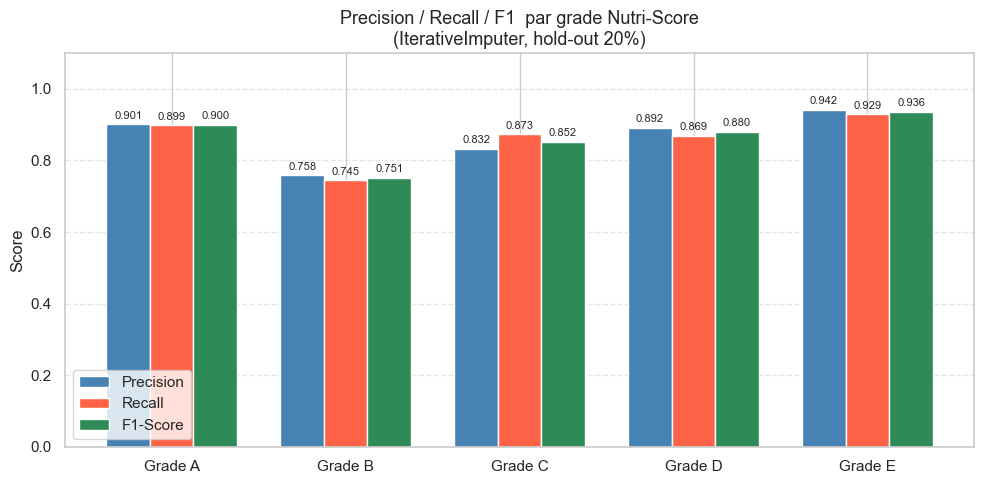

In [37]:
import matplotlib.pyplot as plt
import numpy as np

grades = ['a', 'b', 'c', 'd', 'e']
precisions = [report[g]['precision'] for g in grades]
recalls    = [report[g]['recall']    for g in grades]
f1s        = [report[g]['f1-score']  for g in grades]

x = np.arange(len(grades))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w,     precisions, w, label='Precision', color='steelblue')
bars2 = ax.bar(x,         recalls,    w, label='Recall',    color='tomato')
bars3 = ax.bar(x + w,     f1s,        w, label='F1-Score',  color='seagreen')

# Annotations
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'Grade {g.upper()}' for g in grades], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1  par grade Nutri-Score\n(IterativeImputer, hold-out 20%)', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

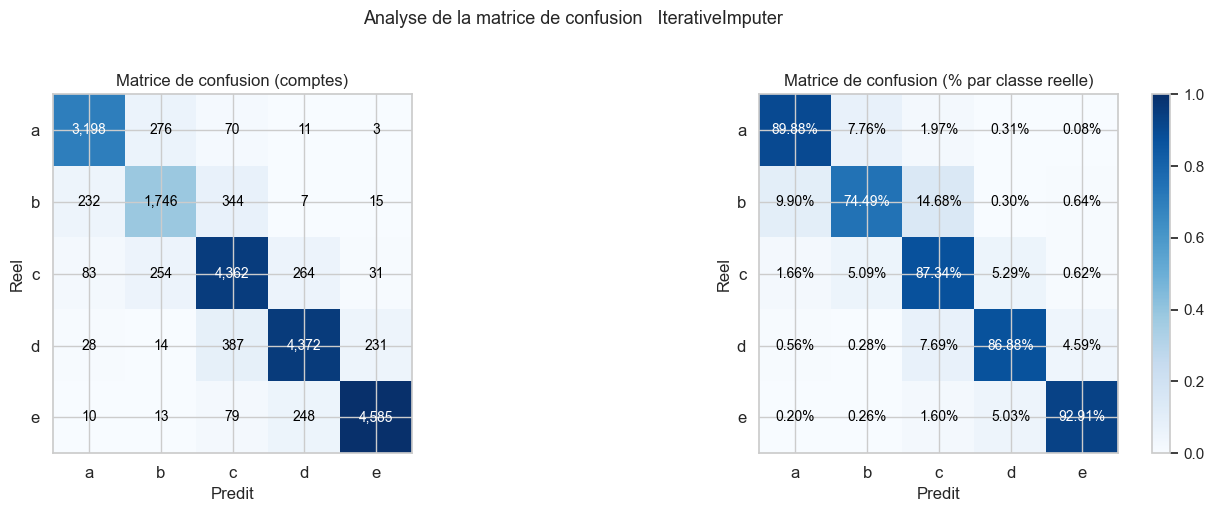

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

labels = ['a', 'b', 'c', 'd', 'e']
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise par ligne

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : comptes absolus
im0 = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks(range(len(labels)))
axes[0].set_yticks(range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].set_yticklabels(labels, fontsize=12)
axes[0].set_xlabel('Predit', fontsize=12)
axes[0].set_ylabel('Reel', fontsize=12)
axes[0].set_title('Matrice de confusion (comptes)', fontsize=12)
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[0].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()*0.6 else 'black', fontsize=10)

# Droite : taux normalise par ligne
im1 = axes[1].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[1].set_xticks(range(len(labels)))
axes[1].set_yticks(range(len(labels)))
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_yticklabels(labels, fontsize=12)
axes[1].set_xlabel('Predit', fontsize=12)
axes[1].set_ylabel('Reel', fontsize=12)
axes[1].set_title('Matrice de confusion (% par classe reelle)', fontsize=12)
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[1].text(j, i, f'{cm_norm[i,j]:.2%}', ha='center', va='center',
                     color='white' if cm_norm[i,j] > 0.6 else 'black', fontsize=10)

plt.colorbar(im1, ax=axes[1])
plt.suptitle('Analyse de la matrice de confusion   IterativeImputer', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Prediction sur les produits sans Nutri-Score

In [39]:
features_pred = [f for f in features_dispo if f in df_pred.columns]
X_pred = df_pred[features_pred]

# Prediction
pred_grades = pipeline.predict(X_pred)

df_pred_out = df_pred.copy()
df_pred_out['nutriscore_grade_predit'] = pred_grades

print(f"Produits predits : {len(df_pred_out):,}")
print("\nDistribution des grades predits :")
print(df_pred_out['nutriscore_grade_predit'].value_counts().sort_index())

Produits predits : 32,394

Distribution des grades predits :
nutriscore_grade_predit
a    4375
b    4429
c    7436
d    7099
e    9055
Name: count, dtype: int64


## 6. Sauvegarde CSV

In [40]:
output_path = 'predictions_sans_nutriscore_iterative.csv'
df_pred_out.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Fichier sauvegarde : {output_path}")

Fichier sauvegarde : predictions_sans_nutriscore_iterative.csv
